# Import Libraries:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Import the dataset:

In [3]:
df = pd.read_csv(r"D:\Ai ml\Projects_ALL\Assesment-Point\data\raw\train-test.csv")

In [4]:
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [5]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


(48000, 14)

In [6]:
df.dtypes

load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

In [7]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


**Oh! I was gonna check for if load_id are all unique or not but as we can see all 48,000 are unique, huff.**

In [9]:
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [10]:
df['weight'].head()

0    30658.0
1    17555.0
2    31721.0
3    32333.0
4    35183.0
Name: weight, dtype: float64

**Ok so we need to use the average or mean value to fill the empty weights as it is only a qantative component**

In [11]:
df["market_index"].head()

0    0.95684
1    0.97623
2    1.00971
3    0.94518
4    0.98480
Name: market_index, dtype: float64

**We can also use the Mean function in it to fill this as it only has float values and the actual fluctuations might depend on other variables so we can calculate a formula to replace all values where it is more suited**

In [12]:
# Determining the formula for market_index:
df_cal = df[['equipment', 'distance', 'weight', 'date', 'market_index', 'quote_signal', 'posted_rate']].iloc[10000:20000:5]



In [13]:

pd.set_option('display.max_rows',100)
df_cal.head(10)

,equipment,distance,weight,date,market_index,quote_signal,posted_rate
10000,Flatbed,2341.2,21444.0,2025-03-05,1.11117,1.95220,4560.79
10005,Dry Van,1703.1,36744.0,2025-03-05,1.15336,1.92703,3268.71
10010,Reefer,950.4,35924.0,2025-03-05,1.12221,2.34556,2228.84
10015,Dry Van,411.3,26530.0,2025-03-05,1.08992,2.30799,949.66
10020,Dry Van,1299.2,29121.0,2025-03-05,1.13748,1.98748,2644.58
10025,Dry Van,865.8,37940.0,2025-03-05,1.12961,2.09638,1825.62
10030,Reefer,554.6,37218.0,2025-03-05,1.10502,2.47540,1374.21
10035,Flatbed,995.9,22143.0,2025-03-05,1.14390,2.13656,2116.62
10040,Dry Van,3022.4,28393.0,2025-03-05,1.12631,1.73904,5268.32
10045,Reefer,1237.6,28195.0,2025-03-05,1.14301,2.25800,2850.07


In [14]:
# Check missing percentage grouped by equipment type:
df.groupby('equipment')[['weight','market_index']].apply(lambda x: x.isna().mean() * 100)

,weight,market_index
equipment,,
Dry Van,0.643335,0.742592
Flatbed,0.628356,0.834000
Reefer,0.581154,0.821918


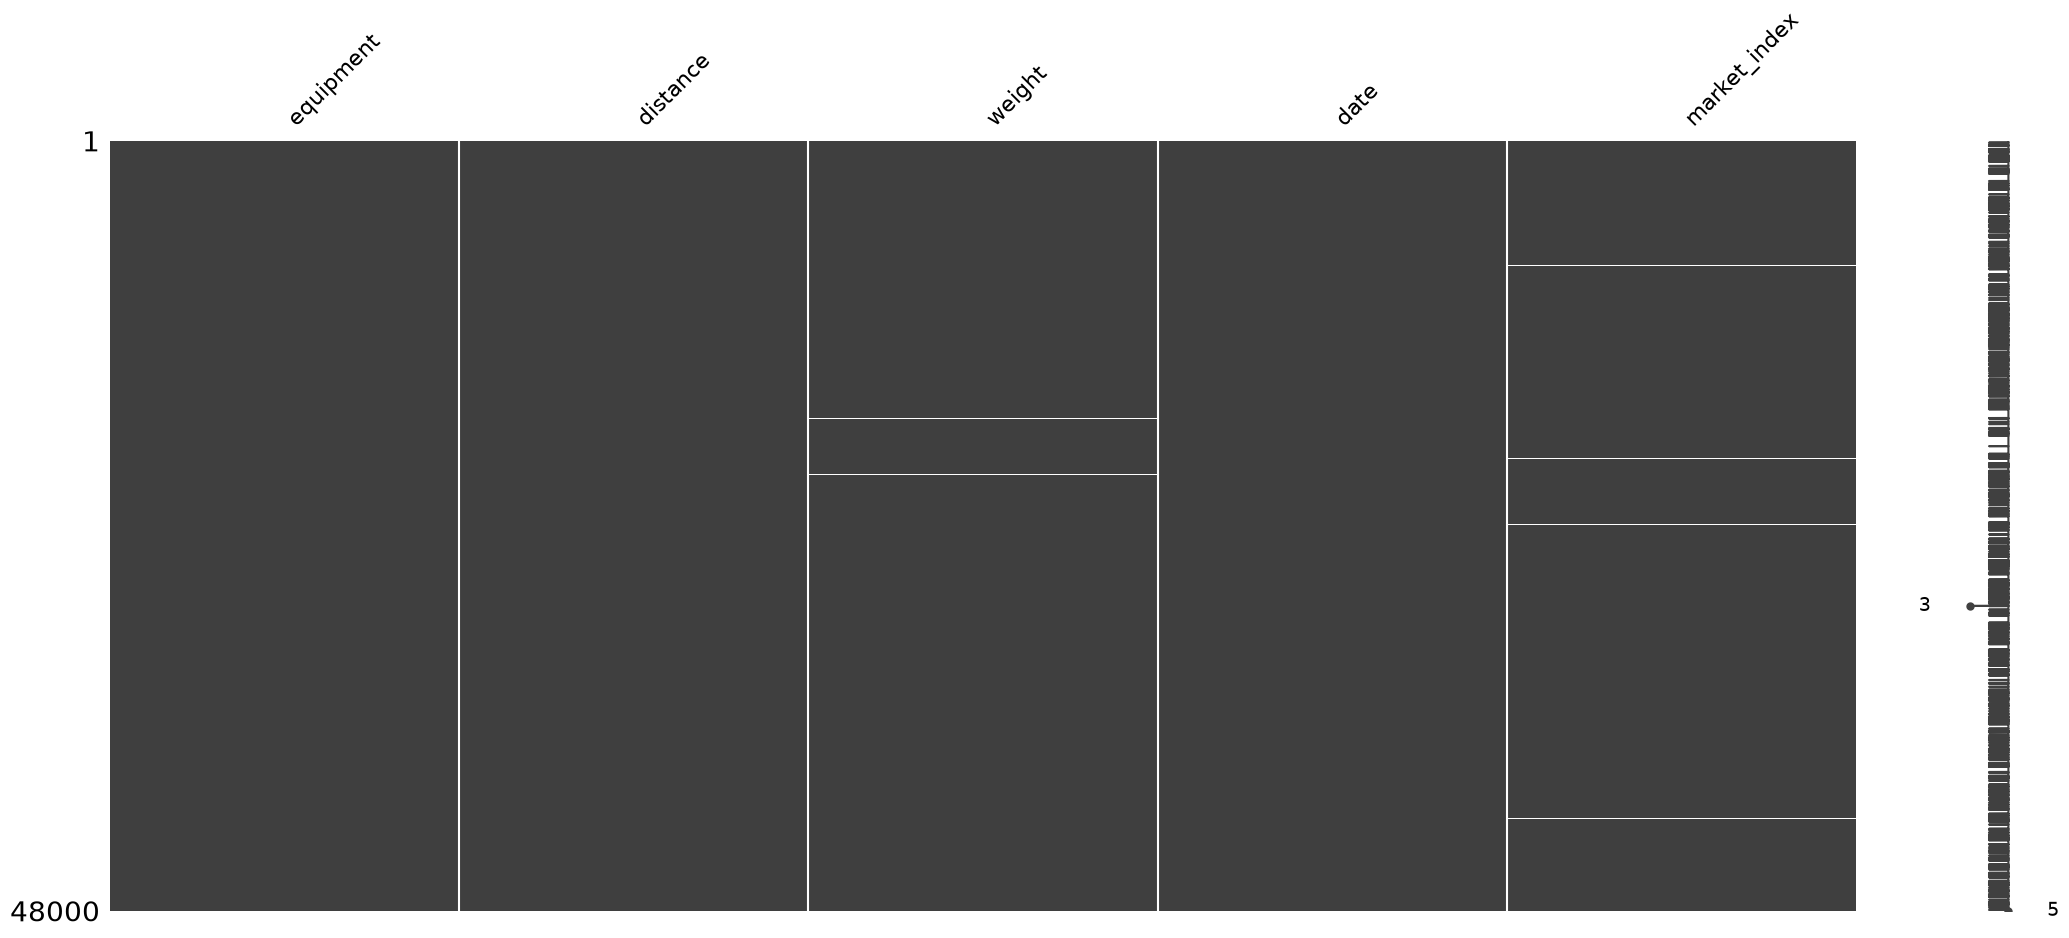

In [15]:
import missingno as msno
import matplotlib.pyplot as plt


columns_to_check = ['equipment', 'distance', 'weight', 'date', 'market_index']
msno.matrix(df[columns_to_check])
plt.show()


In [16]:
# 1. See if a specific equipment type is missing 'market_index'
print(df[df['market_index'].isna()]['equipment'].value_counts())

# 2. See if the missing 'weight' happened on a specific set of dates
print(df[df['weight'].isna()]['date'].unique())


equipment
Dry Van    202
Reefer      99
Flatbed     73
Name: count, dtype: int64
['2025-01-03' '2025-01-05' '2025-01-06' '2025-01-07' '2025-01-08'
 '2025-01-11' '2025-01-12' '2025-01-13' '2025-01-16' '2025-01-19'
 '2025-01-20' '2025-01-23' '2025-01-24' '2025-01-25' '2025-01-27'
 '2025-01-28' '2025-01-29' '2025-01-30' '2025-02-01' '2025-02-05'
 '2025-02-06' '2025-02-07' '2025-02-10' '2025-02-11' '2025-02-12'
 '2025-02-13' '2025-02-14' '2025-02-16' '2025-02-17' '2025-02-19'
 '2025-02-20' '2025-02-22' '2025-02-23' '2025-02-24' '2025-02-25'
 '2025-02-27' '2025-02-28' '2025-03-02' '2025-03-06' '2025-03-07'
 '2025-03-08' '2025-03-09' '2025-03-10' '2025-03-11' '2025-03-12'
 '2025-03-13' '2025-03-14' '2025-03-15' '2025-03-16' '2025-03-17'
 '2025-03-18' '2025-03-19' '2025-03-20' '2025-03-21' '2025-03-22'
 '2025-03-23' '2025-03-25' '2025-03-27' '2025-03-28' '2025-03-29'
 '2025-03-30' '2025-03-31' '2025-04-02' '2025-04-03' '2025-04-04'
 '2025-04-05' '2025-04-06' '2025-04-09' '2025-04-10' '2025-04

In [17]:
# Create a perfectly clean subset for your formula analysis
df_clean = df.dropna(subset=['weight', 'market_index'])
print(f"Clean rows remaining: {len(df_clean)}")


Clean rows remaining: 47327


In [18]:
# Fill missing weight with the median weight of that specific equipment type
df['weight'] = df.groupby('equipment')['weight'].transform(lambda x: x.fillna(x.median()))

# Fill missing market_index with the median index of that specific equipment type
df['market_index'] = df.groupby('equipment')['market_index'].transform(lambda x: x.fillna(x.median()))


# Check Target Variable : posted_rate


In [19]:
df['posted_rate'].describe()


count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

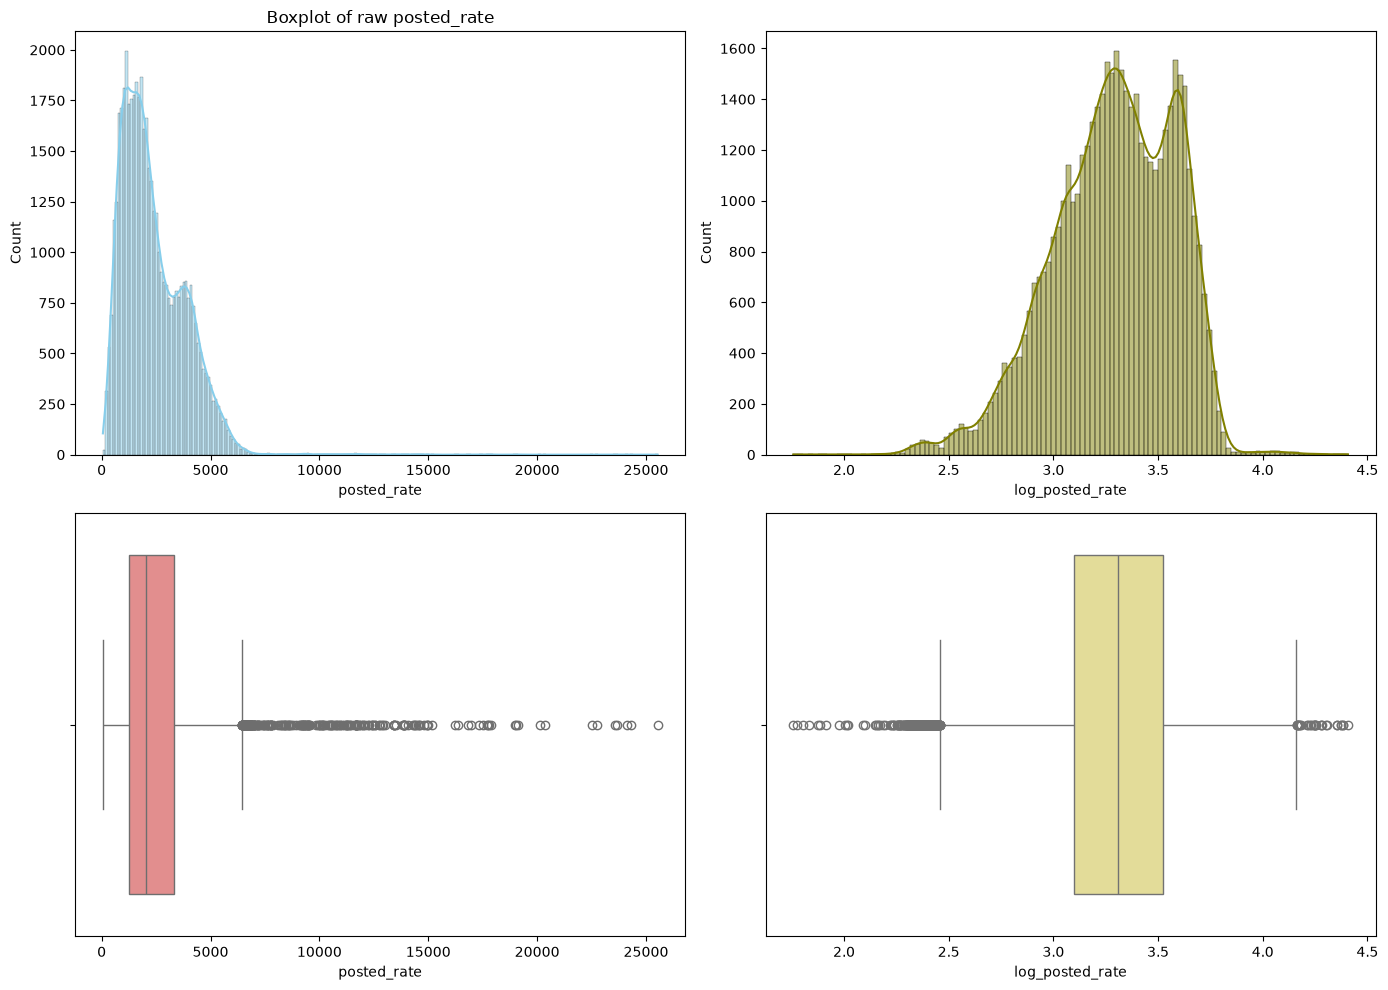

In [20]:
import seaborn as sns

fig, axes =  plt.subplots(2,2, figsize=(14,10))

# Top Left: Histogram of raw posted_rate
sns.histplot(df['posted_rate'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Histogram of raw posted_rate')


# Bottom Left Boxplot of raw posted_rate:
sns.boxplot(x=df['posted_rate'], ax=axes[1,0], color='lightcoral')
axes[0,0].set_title('Boxplot of raw posted_rate')

# Create Log Transformed Column
# Use np.log1p (Log(1+x)) to satisfy handle any potential 0 values smoothly
df['log_posted_rate'] = np.log10(df['posted_rate'])


# Top Right: Histogram of log_transformed_rate (check for normality)
sns.histplot(df['log_posted_rate'], kde=True, ax=axes[0,1], color='olive')
axes[0,0].set_title('Histogram of raw posted_rate')


# Bottom Left Boxplot of raw posted_rate:
sns.boxplot(x=df['log_posted_rate'], ax=axes[1,1], color='khaki')
axes[0,0].set_title('Boxplot of raw posted_rate')

plt.tight_layout()
plt.show()


In [ ]:
# Now we will try to predict some 